### **Attention Mechanism: Additive Attention, Self-Attention Mechanism, Multi-Head Attention Mechanism**

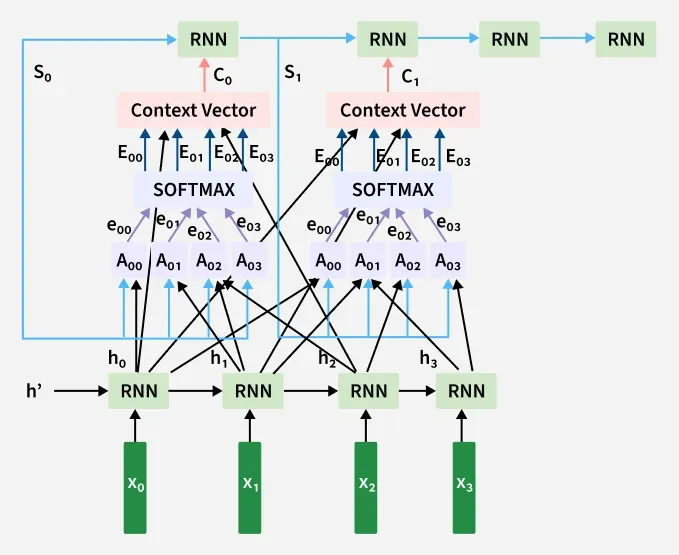

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
  def __init__(self, hidden_dim):
    super(Attention, self).__init__()
    self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
    self.v = nn.Parameter(torch.rand(hidden_dim))

  def forward(self, hidden, encoder_outputs):
    batch_size = encoder_outputs.shape[0]
    seq_len = encoder_outputs.shape[1]
    hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)
    energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
    energy = energy.permute(0, 2, 1)
    v = self.v.repeat(batch_size, 1).unsqueeze(1)
    attention_score = torch.bmm(v, energy).squeeze(1)
    attention_weights = F.softmax(attention_score, dim=1)
    context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)
    return context, attention_weights

In [ ]:
torch.manual_seed(0)

batch_size = 1
seq_len = 4
hidden_dim = 8
encoder_outputs = torch.randn(batch_size, seq_len, hidden_dim)
decoder_hidden = torch.randn(batch_size, hidden_dim)

attention = Attention(hidden_dim)
context, attn_weights = attention(decoder_hidden, encoder_outputs)

print("Encoder Outputs:\n", encoder_outputs)
print("\nDecoder Hidden State:\n", decoder_hidden)
print("\nAttention Weights:\n", attn_weights)
print("\nContext Vector:\n", context)

In [ ]:
import numpy as np

def self_attention(X):
  batch_size, seq_len, d_model = X.shape
  d_k = d_model

  W_q = np.random.randn(d_model, d_k)
  W_k = np.random.randn(d_model, d_k)
  W_v = np.random.randn(d_model, d_k)

  Q = X @ W_q
  K = X @ W_k
  V = X @ W_v

  scores = Q @ K.transpose(0, 2, 1) / np.sqrt(d_k)
  attn_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
  # attn_weights = torch.nn.funtional.softmax(scores)
  output = attn_weights @ V

  return output, attn_weights

In [ ]:
np.random.seed(42)
X = np.random.rand(1, 3, 4)
output, weights = self_attention(X)
print("Output:\n", output)
print("\nAttention Weights:\n", weights)

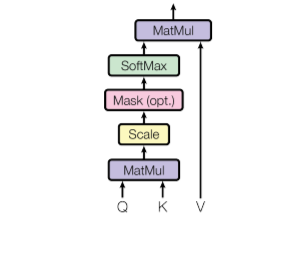

In [ ]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

def scaled_dot_product_attention(q, k, v, mask=None):
  d_k = q.shape[-1]
  scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
  if mask is not None:
    scaled += mask
  attention = F.softmax(scaled, dim=-1)
  values = torch.matmul(attention, v)
  return values, attention

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, input_dim, d_model, num_heads):
    super().__init__()
    self.input_dim = input_dim
    self.d_model = d_model
    self.num_heads = num_heads
    self.head_dim = d_model // num_heads
    self.qkv_layer = nn.Linear(input_dim, 3 * d_model)
    self.linear_layer = nn.Linear(d_model, d_model)

  def forward(self, x, mask=None):
    batch_size, seq_len, input_dim = x.size()
    qkv = self.qkv_layer(x)
    qkv = qkv.reshape(batch_size, seq_len, self.num_heads, 3 * self.head_dim)
    qkv = qkv.permute(0, 2, 1, 3)
    q, k, v = qkv.chunk(3, dim=-1)
    values, attention = scaled_dot_product_attention(q, k, v, mask)
    values = values.permute(0, 2, 1, 3)
    values = values.reshape(batch_size, seq_len, self.num_heads * self.head_dim)
    out = self.linear_layer(values)
    return out

In [ ]:
input_dim = 1024
d_model = 512
num_heads = 8
batch_size = 30
seq_len = 5

x = torch.randn((batch_size, seq_len, input_dim))
model = MultiHeadAttention(input_dim, d_model, num_heads)
out = model.forward(x)
print(out.shape)

In [ ]:
def self_attention_masks(batch_size, seq_len, embedding_dim):
  X = torch.rand(batch_size, seq_len, embedding_dim)
  mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).repeat(batch_size, 1, 1)
  attention_scores = torch.matmul(X, X.transpose(-1, -2)) / (embedding_dim ** 0.5)
  attention_scores = attention_scores.masked_fill(mask == 0, -1e9)
  attention_weights = F.softmax(attention_scores, dim=-1)
  output = torch.matmul(attention_weights, X)
  return output

In [ ]:
seq_len = 5
batch_size = 2
embedding_dim = 4

output = self_attention_masks(batch_size, seq_len, embedding_dim)
print(output)

### **Positional Encoding**

In [ ]:
import numpy as np
import tensorflow as tf

def positional_encoding(position, d_model):
  angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model))

  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

  pos_encoding = angle_rads[np.newaxis, ...]
  return tf.cast(pos_encoding, dtype=tf.float32)

In [ ]:
position = 50
d_model = 512
pos_encoding = positional_encoding(position, d_model)

print("Positional Encodings Shape:", pos_encoding.shape)
print("Positional Encodings Example:\n", pos_encoding)

## **Transformer Model from Scratch using TensorFlow**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import numpy as np

def positional_encoding(position, d_model):
  angle_rads = np.arange(position)[:, np.newaxis] / np.power(
    10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model)
  )
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
  pos_encoding = angle_rads[np.newaxis, ...]

  return tf.cast(pos_encoding, dtype=tf.float32)

class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.num_heads = num_heads
    self.d_model = d_model
    assert d_model % num_heads == 0
    self.depth = d_model // num_heads

    self.wq = Dense(d_model)
    self.wk = Dense(d_model)
    self.wv = Dense(d_model)
    self.dense = Dense(d_model)

  def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])

  def scaled_dot_product_attention(self, q, k, v, mask):
    matmul_qk = tf.matmul(q, k, transpose_b=True)
    df = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(df)
    if mask is not None:
      scaled_attention_logits += (mask * -1e9)
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, v)
    return output, attention_weights

  def call(self, v, k, q, mask=None):
    batch_size = tf.shape(q)[0]

    q = self.wq(q)
    k = self.wk(k)
    v = self.wv(v)

    q = self.split_heads(q, batch_size)
    k = self.split_heads(k, batch_size)
    v = self.split_heads(v, batch_size)

    scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
    concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))
    output = self.dense(concat_attention)

    return output

class PositionWiseFeedForwardNetwork(tf.keras.layers.Layer):
  def __init__(self, d_model, dff):
    super().__init__()
    self.dense1 = Dense(dff, activation="relu")
    self.dense2 = Dense(d_model)

  def call(self, x):
    return self.dense2(self.dense1(x))

class TransformerBlock(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()
    self.att = MultiHeadAttention(d_model, num_heads)
    self.ffn = PositionWiseFeedForwardNetwork(d_model, dff)
    self.layernorm1 = LayerNormalization(epsilon=1e-6)
    self.layernorm2 = LayerNormalization(epsilon=1e-6)
    self.dropout1 = Dropout(dropout_rate)
    self.dropout2 = Dropout(dropout_rate)

  def call(self, x, training=False, mask=None):
    attn_output = self.att(x, x, x, mask=mask)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(x + attn_output)
    ffn_output = self.ffn(out1)
    ffn_output = self.dropout2(ffn_output, training=training)
    out2 = self.layernorm2(out1 + ffn_output)
    return out2

class Encoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
    super().__init__()
    self.d_model = d_model
    self.num_layers = num_layers
    self.embedding = Embedding(input_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
    self.dropout = Dropout(dropout_rate)
    self.enc_layers = [
        TransformerBlock(d_model, num_heads, dff, dropout_rate)
        for _ in range(num_layers)
    ]

  def call(self, x, training=False, mask=None):
    seq_len = tf.shape(x)[1]

    x = self.embedding(x)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]
    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x, training=training, mask=mask)

    return x

class Decoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
    super().__init__()
    self.d_model = d_model
    self.num_layers = num_layers
    self.embedding = Embedding(target_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
    self.dropout = Dropout(dropout_rate)
    self.dec_layers = [
        TransformerBlock(d_model, num_heads, dff, dropout_rate)
        for _ in range(num_layers)
    ]

  def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
    seq_len = tf.shape(x)[1]
    attention_weights = {}

    x = self.embedding(x)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]
    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x = self.dec_layers[i](x, training=training, mask=look_ahead_mask)

    return x, attention_weights

class Transformer(Model):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
    super().__init__()

    self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate)
    self.decoder = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, dropout_rate)
    self.final_layer = Dense(target_vocab_size)

  def call(self, inputs, training=False, look_ahead_mask=None, padding_mask=None):
    inp, tar = inputs
    enc_output = self.encoder(inp, training=training, mask=padding_mask)
    dec_output, _ = self.decoder(tar, enc_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
    final_output = self.final_layer(dec_output)
    return final_output

In [ ]:
num_layers = 2
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = 8500
target_vocab_size = 8000
maximum_position_encoding = 10000
dropout_rate = 0.1

transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    target_vocab_size,
    maximum_position_encoding,
    dropout_rate
)

In [ ]:
inputs = tf.random.uniform((64, 50), dtype=tf.int64, minval=0, maxval=input_vocab_size)
targets = tf.random.uniform((64, 50), dtype=tf.int64, minval=0, maxval=target_vocab_size)
look_ahead_mask = None
padding_mask = None

transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    target_vocab_size,
    maximum_position_encoding,
    dropout_rate
)

outputs = transformer((inputs,targets), training=True, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
print(outputs.shape)

## **Transformer using PyTorch**

In [ ]:
import torch
from torch import nn as nn
from torch import optim as optim
import torch.utils.data as data
import math
import copy

class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    self.w_o = nn.Linear(d_model, d_model)

  def scaled_dot_product_attention(self, Q, K, V, mask=None):
    attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
    if mask is not None:
      attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
    attn_weights = torch.softmax(attn_scores, dim=-1)
    output = torch.matmul(attn_weights, V)
    return output

  def split_heads(self, x):
    batch_size, seq_len, d_model = x.size()
    return x.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

  def combine_heads(self, x):
    batch_size, _, seq_len, d_k = x.size()
    return x.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

  def forward(self, Q, K, V, mask=None):
    Q = self.split_heads(self.w_q(Q))
    K = self.split_heads(self.w_k(K))
    V = self.split_heads(self.w_v(V))

    attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
    output = self.w_o(self.combine_heads(attn_output))
    return output

class PositionWiseFeedForwardNetwork(nn.Module):
  def __init__(self, d_model, dff):
    super(PositionWiseFeedForwardNetwork, self).__init__()
    self.fc1 = nn.Linear(d_model, dff)
    self.fc2 = nn.Linear(dff, d_model)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.fc2(self.relu(self.fc1(x)))

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_seq_len):
    super(PositionalEncoding, self).__init__()
    self.d_model = d_model
    pe = torch.zeros(max_seq_len, d_model)
    position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    self.register_buffer("pe", pe.unsqueeze(0))

  def forward(self, x):
    return x + self.pe[:, :x.size(1)]

class EncoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, dff, dropout_rate):
    super(EncoderLayer, self).__init__()
    self.self_attention = MultiHeadAttention(d_model, num_heads)
    self.ffn = PositionWiseFeedForwardNetwork(d_model, dff)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.dropout = nn.Dropout(dropout_rate)

  def forward(self, x, mask):
    attn_output = self.self_attention(x, x, x, mask)
    x = self.norm1(x + self.dropout(attn_output))
    ffn_output = self.ffn(x)
    x = self.norm2(x + self.dropout(ffn_output))
    return x

class DecoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, dff, dropout_rate):
    super(DecoderLayer, self).__init__()
    self.self_attention = MultiHeadAttention(d_model, num_heads)
    self.cross_attention = MultiHeadAttention(d_model, num_heads)
    self.ffn = PositionWiseFeedForwardNetwork(d_model, dff)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)
    self.dropout = nn.Dropout(dropout_rate)

  def forward(self, x, enc_output, src_mask, tgt_mask):
    attn_output = self.self_attention(x,x,x, tgt_mask)
    x = self.norm1(x + self.dropout(attn_output))
    attn_output = self.cross_attention(x, enc_output, enc_output, src_mask)
    x = self.norm2(x + self.dropout(attn_output))
    ff_output = self.ffn(x)
    x = self.norm3(x + self.dropout(ff_output))
    return x

class Transformer(nn.Module):
  def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, dff, max_seq_len, dropout_rate):
    super(Transformer, self).__init__()
    self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
    self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
    self.positional_encoding = PositionalEncoding(d_model, max_seq_len)
    self.encoder_layers = nn.ModuleList([
        EncoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)
    ])
    self.decoder_layers = nn.ModuleList([
        DecoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)
    ])
    self.fc = nn.Linear(d_model, tgt_vocab_size)
    self.dropout = nn.Dropout(dropout_rate)

  def generate_mask(self, src, tgt):
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
    seq_length = tgt.size(1)
    nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
    tgt_mask = tgt_mask & nopeak_mask
    return src_mask, tgt_mask

  def forward(self, src, tgt):
    src_mask, tgt_mask = self.generate_mask(src, tgt)
    src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
    tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

    enc_output = src_embedded
    for enc_layer in self.encoder_layers:
      enc_output = enc_layer(enc_output, src_mask)

    dec_output = tgt_embedded
    for dec_layer in self.decoder_layers:
      dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

    output = self.fc(dec_output)
    return output

In [ ]:
src_vocab_size = 5000
tgt_vocab_size = 5000
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 100
dropout = 0.1

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))
tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)
transformer.train()

for epoch in range(100):
  optimizer.zero_grad()
  output = transformer(src_data, tgt_data[:, :-1])
  loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
  loss.backward()
  optimizer.step()
  print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

In [ ]:
transformer.eval()

val_src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))
val_tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))

with torch.no_grad():

    val_output = transformer(val_src_data, val_tgt_data[:, :-1])
    val_loss = criterion(val_output.contiguous().view(-1, tgt_vocab_size), val_tgt_data[:, 1:].contiguous().view(-1))
    print(f"Validation Loss: {val_loss.item()}")